# Часть 1: Реализация метода k-ближайших соседей (kNN) и метрик расстояния


## Задание 1.1: Реализация метрик расстояния

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import time
import heapq
from sklearn.naive_bayes import MultinomialNB, ComplementNB
import pandas as pd
from sklearn.metrics import confusion_matrix as sk_cm

# Метрики расстояния
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=1)

def cosine_distance (a, b):
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a, axis=1)
    norm_b = np.linalg.norm(b)
    similarity = dot / (norm_a * norm_b + 1e-8)
    return 1 - similarity

## Задание 1.2: Реализация алгоритма kNN (Brute-Force)

In [45]:
# Класс алгоритма
class MyKNN:
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test, k=3, metric='euclidean'):
        result = []
        for x in X_test:
            distances = []
            if metric == 'euclidean':
                distances = euclidean_distance(self.X_train, x)
            elif metric == 'manhattan':
                distances = manhattan_distance(self.X_train, x)
            elif metric == 'cosine':
                distances = cosine_distance(self.X_train, x)
            else:
                raise ValueError("Invalid value")
            knn_indexes = np.argsort(distances)[:k]
            targets = self.y_train[knn_indexes]
            tag = np.bincount(targets).argmax()
            result.append(tag)
        return np.array(result)

## Задание 1.3 Сравнение метрик и параметра к

Pred - [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
Test - [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
Accuracy: 1.00
Precision: [1. 1. 1.]
Recall: [1. 1. 1.]


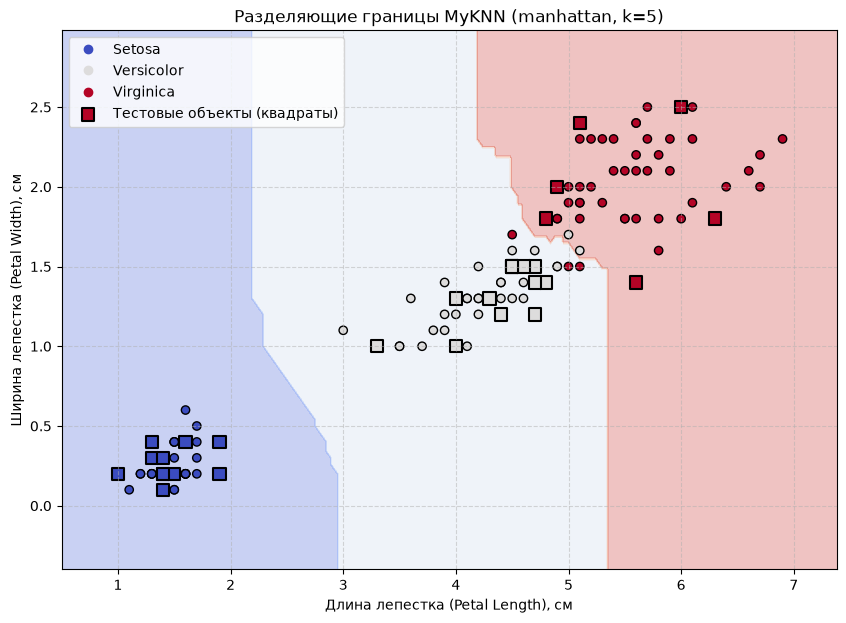

In [47]:
# обучение
X1, y1 = load_iris(return_X_y=True, as_frame=False)
# X1_test - dataset, X1_train - train set, y1_test - right answers, y1_train - right answers for model
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=0)
knn_clf = MyKNN() # K nearest neighbors classificator
knn_clf.fit(X1_train, y1_train)
knn_clf_pred_res = knn_clf.predict(X1_test, 5, 'cosine')
print(f"Pred - {knn_clf_pred_res}")
print(f"Test - {y1_test}")
# метрики качества
accuracy = accuracy_score(y1_test, knn_clf_pred_res)
print(f"Accuracy: {accuracy:.2f}")
precision = precision_score(y1_test, knn_clf_pred_res, average=None)
print(f"Precision: {precision}")
recall = recall_score(y1_test, knn_clf_pred_res, average=None)
print(f"Recall: {recall}")

# 1. Отбираем только нужные признаки: Petal Length (индекс 2) и Petal Width (индекс 3)
# В датасете Iris порядок признаков: sepal length, sepal width, petal length, petal width
X_pairs = X1[:, [2, 3]] 

# Разделяем на train/test с теми же параметрами
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pairs, y1, test_size=0.2, random_state=0
)

# Обучаем модель MyKNN на двух признаках
knn_best = MyKNN()
knn_best.fit(X_train_p, y_train_p)

# Параметры лучшей модели из таблицы
BEST_K = 5
BEST_METRIC = 'manhattan' # или 'cosine'

# 2. Создаем сетку точек для отображения разделяющих границ
x_min, x_max = X_pairs[:, 0].min() - 0.5, X_pairs[:, 0].max() + 0.5
y_min, y_max = X_pairs[:, 1].min() - 0.5, X_pairs[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Предсказываем класс для каждой точки сетки
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn_best.predict(grid_points, k=BEST_K, metric=BEST_METRIC)
Z = Z.reshape(xx.shape)

# 3. Рисуем график
plt.figure(figsize=(10, 7))

# Заливка фона
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Отображаем обучающую выборку
scatter_train = plt.scatter(X_train_p[:, 0], X_train_p[:, 1], c=y_train_p, 
                            cmap=plt.cm.coolwarm, edgecolors='k', label='Обучающая выборка')

# Выделяем тестовую выборку
scatter_test = plt.scatter(X_test_p[:, 0], X_test_p[:, 1], c=y_test_p, 
                           cmap=plt.cm.coolwarm, marker='s', s=80, edgecolors='black', linewidths=1.5, label='Тестовая выборка')

# Оформление графика
plt.xlabel('Длина лепестка (Petal Length), см')
plt.ylabel('Ширина лепестка (Petal Width), см')
plt.title(f'Разделяющие границы MyKNN ({BEST_METRIC}, k={BEST_K})')
plt.legend(handles=scatter_train.legend_elements()[0] + [scatter_test], 
           labels=['Setosa', 'Versicolor', 'Virginica', 'Тестовые объекты (квадраты)'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Часть 2: Реализация древовидных структур для ускорения kNN (BallTree / KD-Tree)

## Задание 2.1: Реализация BallTree

In [30]:
# класс дерева
class BallTree:
    # класс узла
    class Node:
        def __init__(self, centroid, radius, indices=None, left=None, right=None):
            self.centroid = centroid
            self.radius = radius
            self.indices = indices
            self.left = left
            self.right = right

        @property
        def is_leaf(self):
            return self.left is None and self.right is None

    def __init__(self, leaf_size=10):
        self.leaf_size = leaf_size
        self.root = None # корень дерева
        self.data = None # наши данные для обучения

    # выбор оси с наибольшей дисперсией
    def __pick_dimension(self, points):
        return int(np.argmax(points.max(axis=0) - points.min(axis=0)))

    # найти индекс центроида
    def __get_centroid_index(self, points, dimension):
        return int(np.argmin(np.abs(points[:, dimension] - points[:, dimension].mean())))

    # найти радиус гиперсферы
    def __get_radius(self, centroid, points):
        return float(np.max(np.linalg.norm(points - centroid, axis=1)))

    # построить дерево (публичный метод)
    def build_tree(self, data, leaf_size=None):
        if leaf_size is not None:
            self.leaf_size = leaf_size
        self.data = np.asarray(data, dtype=float)
        self.root = self.__build(np.arange(len(self.data))) # передаем диапазон индексов 1, 2, ..., n-1
        return self.root

    # рекурсивный метод построения дерева
    def __build(self, indices):
        points = self.data[indices] # выбираем множество точек
        dimension = self.__pick_dimension(points)
        order = np.argsort(points[:, dimension], kind='stable') # получаем порядок для сортировки
        indices, points = indices[order], points[order] # сортируем

        centroid_pos = self.__get_centroid_index(points, dimension)
        centroid = points[centroid_pos]
        radius = self.__get_radius(centroid, points)

        # условие выхода из рекурсии
        if len(indices) <= self.leaf_size:
            return self.Node(centroid, radius, indices=indices)

        # разделяем на части: до центроида и после, левая = часть [0, centroid_pos], правая = (centroid_pos, n-1]
        split = centroid_pos + 1
        # если centroid_pos указывает на последний элемент, тогда просто берем середину
        if split >= len(indices):
            split = len(indices) // 2

        left = self.__build(indices[:split])
        right = self.__build(indices[split:])
        return self.Node(centroid, radius, left=left, right=right)

    # обход дерева
    def query(self, point, k=1):
        """Возвращает (расстояния, индексы) k ближайших точек, по возрастанию расстояния."""
        point = np.asarray(point, dtype=float)
        heap = []  # элементы: (-расстояние, индекс); вершина = самый дальний из k
        self.__search(self.root, point, k, heap)

        result = sorted((-d, i) for d, i in heap) # сортируем по порядку 
        dists = np.array([d for d, _ in result]) # берем расстояния
        idxs = np.array([i for _, i in result]) # берем индексы
        return dists, idxs

    # обход дерева рекурсивный
    def __search(self, node, point, k, heap):
        # расстояние от текущей точки до центроида в другом узле
        d_centroid = np.linalg.norm(point - node.centroid)

        # отсечение: даже самая близкая возможная точка узла не лучше k-го кандидата
        if len(heap) == k and d_centroid - node.radius >= -heap[0][0]:
            return

        if node.is_leaf:
            # полный перебор внутри листа
            dists = np.linalg.norm(self.data[node.indices] - point, axis=1)
            for d, idx in zip(dists, node.indices):
                if len(heap) < k:
                    heapq.heappush(heap, (-d, int(idx)))
                elif d < -heap[0][0]:
                    heapq.heapreplace(heap, (-d, int(idx)))
            return

        # сначала идём в ближайший по центроиду дочерний узел
        d_left = np.linalg.norm(point - node.left.centroid)
        d_right = np.linalg.norm(point - node.right.centroid)
        first, second = (node.left, node.right) if d_left <= d_right else (node.right, node.left)

        self.__search(first, point, k, heap)
        self.__search(second, point, k, heap)

## Задание 2.2: Реализация KD-Tree

In [31]:
# класс дерева
class KDTree:
    # класс узла
    class Node:
        def __init__(self, axis=None, median=None, indices=None, left=None, right=None):
            self.axis = axis        # ось, по которой делили
            self.median = median    # значение медианы по этой оси (гиперплоскость)
            self.indices = indices  # индексы точек (только у листа)
            self.left = left
            self.right = right

        @property
        def is_leaf(self):
            return self.left is None and self.right is None

    def __init__(self, leaf_size=10):
        self.leaf_size = leaf_size
        self.root = None
        self.data = None
        
    # выбор оси с наибольшей дисперсией
    def __pick_dimension(self, points):
        return int(np.argmax(points.var(axis=0)))

    # построить дерево (публичный метод)
    def build_tree(self, data, leaf_size=None):
        if leaf_size is not None:
            self.leaf_size = leaf_size
        self.data = np.asarray(data, dtype=float)
        self.root = self.__build(np.arange(len(self.data)))
        return self.root

    # рекурсивный метод построения дерева
    def __build(self, indices):
        # лист: точек мало
        if len(indices) <= self.leaf_size:
            return self.Node(indices=indices)

        points = self.data[indices]
        axis = self.__pick_dimension(points)

        # сортируем по оси и делим по медиане
        order = np.argsort(points[:, axis], kind='stable')
        indices = indices[order]
        mid = len(indices) // 2
        median = self.data[indices[mid], axis]

        # слева значения <= median, справа >= median
        left = self.__build(indices[:mid])
        right = self.__build(indices[mid:])
        return self.Node(axis=axis, median=median, left=left, right=right)

    # обход дерева
    def query(self, point, k=1):
        """Возвращает (расстояния, индексы) k ближайших точек по возрастанию расстояния."""
        point = np.asarray(point, dtype=float)
        heap = []  # (-расстояние, индекс)
        self.__search(self.root, point, k, heap)

        result = sorted((-d, i) for d, i in heap)
        dists = np.array([d for d, _ in result])
        idxs = np.array([i for _, i in result])
        return dists, idxs

    # обход дерева рекурсивный
    def __search(self, node, point, k, heap):
        if node.is_leaf:
            dists = np.linalg.norm(self.data[node.indices] - point, axis=1)
            for d, idx in zip(dists, node.indices):
                if len(heap) < k:
                    heapq.heappush(heap, (-d, int(idx)))
                elif d < -heap[0][0]:
                    heapq.heapreplace(heap, (-d, int(idx)))
            return

        # с какой стороны гиперплоскости лежит запрос
        diff = point[node.axis] - node.median
        near, far = (node.left, node.right) if diff < 0 else (node.right, node.left)

        # сначала ближняя сторона
        self.__search(near, point, k, heap)

        # дальнюю смотрим, только если плоскость ближе, чем k-й кандидат
        if len(heap) < k or abs(diff) < -heap[0][0]:
            self.__search(far, point, k, heap)

## Задание 2.3: Интеграция с KNN

In [32]:
# Класс алгоритма
class MyKNN:
    def fit(self, X_train, y_train, algorithm=None, leaf_size=10):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        self.tree = None
        # деревья строятся один раз, при обучении
        if algorithm == 'ball_tree':
            self.tree = BallTree(leaf_size)
            self.tree.build_tree(self.X_train)
        elif algorithm == 'kd_tree':
            self.tree = KDTree(leaf_size)
            self.tree.build_tree(self.X_train)
        elif algorithm is not None:
            raise ValueError("Invalid value")
        self.fitted_algorithm = algorithm

    def predict(self, X_test, k=3, metric='euclidean', algorithm=None):
        if algorithm is None:
            result = []
            for x in X_test:
                if metric == 'euclidean':
                    distances = euclidean_distance(self.X_train, x)
                elif metric == 'manhattan':
                    distances = manhattan_distance(self.X_train, x)
                elif metric == 'cosine':
                    distances = cosine_distance(self.X_train, x)
                else:
                    raise ValueError("Invalid value")
                knn_indexes = np.argsort(distances)[:k]
                targets = self.y_train[knn_indexes]
                result.append(np.bincount(targets).argmax())
            return np.array(result)

        elif algorithm in ('ball_tree', 'kd_tree'):
            if metric != 'euclidean':
                raise ValueError("Деревья реализованы только для евклидовой метрики")
            # если дерево нужного типа не построено в fit, строим здесь
            if self.tree is None or self.fitted_algorithm != algorithm:
                cls = BallTree if algorithm == 'ball_tree' else KDTree
                self.tree = cls(10)
                self.tree.build_tree(self.X_train)
                self.fitted_algorithm = algorithm
            return self.__predict_tree(X_test, k)

        else:
            raise ValueError("Invalid value")

    def __predict_tree(self, X_test, k):
        result = []
        for x in X_test:
            _, idxs = self.tree.query(x, k)
            result.append(np.bincount(self.y_train[idxs]).argmax())
        return np.array(result)

# Часть 3: Метрики бинарной классификации

## Задание 3.1: Бинаризация задачи

In [33]:
POSITIVE_CLASS = 0
def binarize(y, positive_class=POSITIVE_CLASS):
    # 1 - если объект принадлежит выбранному классу, иначе 0
    return (y == positive_class).astype(int)

# бинаризуем уже существующие метки из 1.3
y1_bin = binarize(y1)
y1_train_bin = binarize(y1_train)
y1_test_bin = binarize(y1_test)

print("y1:", y1)
print("y1_train:", y1_train)
print("y1_train:", y1_test_bin)

names = load_iris().target_names
print(f"Положительный класс (1): {names[POSITIVE_CLASS]}")
print(f"Отрицательный класс (0): {', '.join(n for i, n in enumerate(names) if i != POSITIVE_CLASS)}")

print("\nВся выборка:  ", dict(zip(*np.unique(y1_bin, return_counts=True))))
print("Обучающая:    ", dict(zip(*np.unique(y1_train_bin, return_counts=True))))
print("Тестовая:     ", dict(zip(*np.unique(y1_test_bin, return_counts=True))))

print("\nБыло (3 класса):", y1_test[:10])
print("Стало (2 класса):", y1_test_bin[:10])

y1: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
y1_train: [2 1 0 2 2 1 0 1 1 1 2 0 2 0 0 1 2 2 2 2 1 2 1 1 2 2 2 2 1 2 1 0 2 1 1 1 1
 2 0 0 2 1 0 0 1 0 2 1 0 1 2 1 0 2 2 2 2 0 0 2 2 0 2 0 2 2 0 0 2 0 0 0 1 2
 2 0 0 0 1 1 0 0 1 0 2 1 2 1 0 2 0 2 0 0 2 0 2 1 1 1 2 2 1 1 0 1 2 2 0 1 1
 1 1 0 0 0 2 1 2 0]
y1_train: [0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 0 0 1]
Положительный класс (1): setosa
Отрицательный класс (0): versicolor, virginica

Вся выборка:   {np.int64(0): np.int64(100), np.int64(1): np.int64(50)}
Обучающая:     {np.int64(0): np.int64(81), np.int64(1): np.int64(39)}
Тестовая:      {np.int64(0): np.int64(19), np.int64(1): np.int64(11)}

Было (3 класса): [2 1 0 2 0 2 0 1 1 1]
Стало (2 класса): [0 0 1 0 1 0 1

## Задание 3.2: Расчет метрик классификации "с нуля"

In [34]:
# возвращает матрицу ошибок
def confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # & - поэлементарное логическое умножение 2-ух массивов
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    return np.array([[TN, FP], [FN, TP]])
    
# считает precision на основе матрицы ошибок
def precision(y_true, y_pred):
    (TN, FP), (FN, TP) = confusion_matrix(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0 
# считает recall
def recall (y_true, y_pred):
    (TN, FP), (FN, TP) = confusion_matrix(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0
# считает f1_score
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0
def accuracy(y_true, y_pred):
    (TN, FP), (FN, TP) = confusion_matrix(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

## Задание 3.3: Построение ROC-кривой и расчет AUC

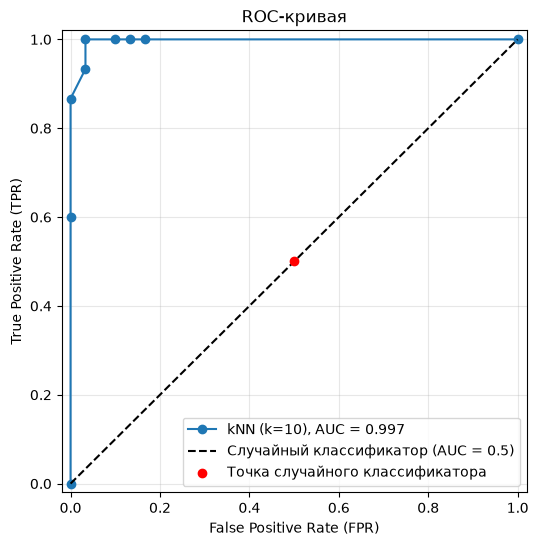

AUC = 0.9967
Моя AUC:      0.996667
sklearn AUC:  0.996667


In [35]:
X, y = load_iris(return_X_y=True)
y_bin = (y == 2).astype(int)          # virginica = 1, остальные = 0

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=0, stratify=y_bin)

def knn_scores(X_train, y_train, X_test, k=10):
    """Оценка = доля соседей положительного класса среди k ближайших."""
    scores = []
    for x in X_test:
        dist = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
        nn = np.argsort(dist)[:k]
        scores.append(y_train[nn].mean())
    return np.array(scores)

y_scores = knn_scores(X_train, y_train, X_test, k=10)

def roc_curve(y_true, y_scores):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    thresholds = np.unique(np.concatenate([y_scores, [0.0, 1.0]]))[::-1]
    thresholds = np.concatenate([[1.0 + 1e-9], thresholds])

    fpr, tpr = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        (TN, FP), (FN, TP) = confusion_matrix(y_true, y_pred)
        tpr.append(recall(y_true, y_pred))
        fpr.append(FP / (FP + TN) if (FP + TN) > 0 else 0.0)
    return np.array(fpr), np.array(tpr), thresholds


def auc(fpr, tpr):
    # метод трапеций: сумма (ширина * средняя высота)
    area = 0.0
    for i in range(1, len(fpr)):
        area += (fpr[i] - fpr[i - 1]) * (tpr[i] + tpr[i - 1]) / 2
    return area

fpr, tpr, thr = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker='o', label=f'kNN (k=10), AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.scatter([0.5], [0.5], color='red', zorder=5, label='Точка случайного классификатора')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.xlim(-0.02, 1.02); plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()

print(f"AUC = {roc_auc:.4f}")
print("Моя AUC:     ", round(roc_auc, 6))
print("sklearn AUC: ", round(roc_auc_score(y_test, y_scores), 6))

# Часть 4: Реализация наивных байесовских классификаторов

## Задание 4.1: Гауссовский наивный байесовский классификатор (GaussianNB)

Accuracy (4 признака): 1.0000
Accuracy (пара признаков ['petal length (cm)', 'petal width (cm)']): 1.0000


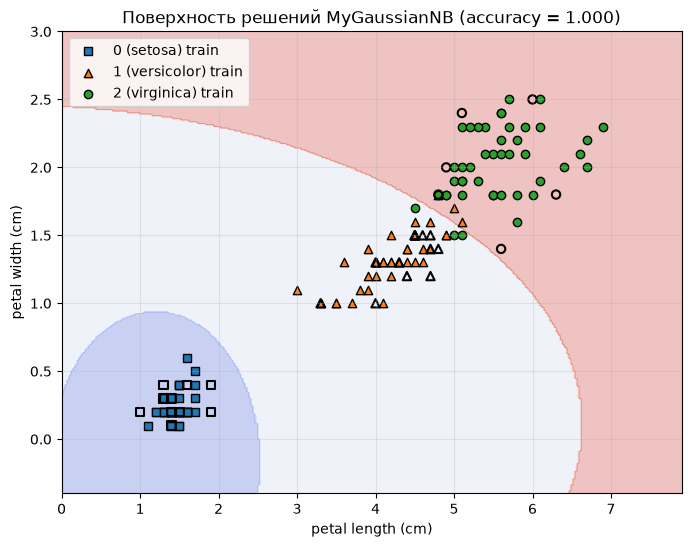

In [13]:
class MyGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        # 1e-9 чтобы не делить на 0
        self.var_smoothing = var_smoothing

    def fit(self, X_train, y_train):
        X = np.asarray(X_train, dtype=float)
        y = np.asarray(y_train)

        self.classes_ = np.unique(y)
        n_classes, n_features = len(self.classes_), X.shape[1]

        self.log_prior_ = np.zeros(n_classes)
        self.mu_ = np.zeros((n_classes, n_features))
        self.sigma_ = np.zeros((n_classes, n_features))

        eps = self.var_smoothing * X.var(axis=0).max()

        for i, c in enumerate(self.classes_):
            Xc = X[y == c] # объекты только класса c
            self.log_prior_[i] = np.log(len(Xc) / len(X)) # log P(c)
            self.mu_[i] = Xc.mean(axis=0) # среднее по каждому признаку
            self.sigma_[i] = np.sqrt(Xc.var(axis=0) + eps) # стандартное отклонение
        return self

    def predict_proba(self, X_test):
        # возвращает логарифм апостериорной вероятности (без нормировки).
        X = np.asarray(X_test, dtype=float)
        log_post = np.zeros((X.shape[0], len(self.classes_)))

        for i in range(len(self.classes_)):
            mu, sigma = self.mu_[i], self.sigma_[i]
            # log плотности нормального распределения для каждого признака
            log_pdf = -0.5 * np.log(2 * np.pi * sigma**2) - (X - mu)**2 / (2 * sigma**2)
            # log P(c) + сумма по признакам
            log_post[:, i] = self.log_prior_[i] + log_pdf.sum(axis=1)
        return log_post

    def predict(self, X_test):
        return self.classes_[np.argmax(self.predict_proba(X_test), axis=1)]


# обучение на всех 4 признаках
gnb = MyGaussianNB().fit(X1_train, y1_train)
y_pred_gnb = gnb.predict(X1_test)
print(f"Accuracy (4 признака): {accuracy(y1_test, y_pred_gnb):.4f}")

cols = [2, 3]
feat_names = ['petal length (cm)', 'petal width (cm)']

gnb2 = MyGaussianNB().fit(X1_train[:, cols], y1_train)
acc2 = accuracy(y1_test, gnb2.predict(X1_test[:, cols]))
print(f"Accuracy (пара признаков {feat_names}): {acc2:.4f}")

# решающие границы
X_2d = X1[:, cols]
xx, yy = np.meshgrid(
    np.linspace(X_2d[:, 0].min() - 1,   X_2d[:, 0].max() + 1,   300),
    np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 300))
Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
for c, marker, name in zip([0, 1, 2], ['s', '^', 'o'], load_iris().target_names):
    m = y1_train == c
    plt.scatter(X1_train[m, cols[0]], X1_train[m, cols[1]], marker=marker,
                edgecolor='k', label=f'{c} ({name}) train')
    m = y1_test == c
    plt.scatter(X1_test[m, cols[0]], X1_test[m, cols[1]], marker=marker,
                edgecolor='k', facecolor='none', linewidth=1.5)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f'Поверхность решений MyGaussianNB (accuracy = {acc2:.3f})')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Задание 4.2: Мультиномиальный наивный байесовский классификатор (MultinomialNB)

In [38]:
rng = np.random.RandomState(42)

vocab = ["мяч", "гол", "матч", "выборы", "закон", "партия",
         "процессор", "код", "сеть", "новости", "сегодня", "год"]

# вероятность каждого слова в каждой категории (строки нормируем на 1)
class_word_probs = np.array([
    # мяч  гол  матч  выбор закон парт  проц  код  сеть новос сегод год
    [0.20, 0.20, 0.20, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.10, 0.10, 0.08],  # 0: спорт
    [0.02, 0.02, 0.02, 0.20, 0.20, 0.20, 0.02, 0.02, 0.02, 0.10, 0.10, 0.08],  # 1: политика
    [0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.20, 0.20, 0.20, 0.10, 0.10, 0.08],  # 2: технологии
])
class_word_probs /= class_word_probs.sum(axis=1, keepdims=True)

n_docs_per_class = 200
doc_length = 10   # слов в документе (короткие документы делают задачу не такой тривиальной)

X_doc, y_doc = [], []
for c in range(3):
    for _ in range(n_docs_per_class):
        # документ = вектор частот слов (мультиномиальное распределение)
        X_doc.append(rng.multinomial(doc_length, class_word_probs[c]))
        y_doc.append(c)
X_doc, y_doc = np.array(X_doc), np.array(y_doc)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_doc, y_doc, test_size=0.3, random_state=0, stratify=y_doc)

print("train:", Xd_train.shape, "test:", Xd_test.shape)
print("Первый документ:", {w: int(n) for w, n in zip(vocab, Xd_train[0]) if n > 0})

class MyMultinomialNB:
    def __init__(self, alpha=1.0):
        # alpha = 1 это сглаживание Лапласа
        self.alpha = alpha

    def fit(self, X_train, y_train):
        X = np.asarray(X_train, dtype=float)
        y = np.asarray(y_train)

        self.classes_ = np.unique(y)
        n_classes, n_features = len(self.classes_), X.shape[1]

        self.log_prior_ = np.zeros(n_classes)              # log P(c)
        self.log_prob_ = np.zeros((n_classes, n_features)) # log P(x_i | c)

        for i, c in enumerate(self.classes_):
            Xc = X[y == c]                                  # документы только класса c
            self.log_prior_[i] = np.log(len(Xc) / len(X))   # P(c) = N_c / N

            # N_ic: сколько раз слово i встретилось во всех документах класса c
            counts = Xc.sum(axis=0)
            # сглаживание Лапласа: (N_ic + alpha) / (sum_j N_jc + alpha * n)
            smoothed = counts + self.alpha
            self.log_prob_[i] = np.log(smoothed / smoothed.sum())
        return self

    def predict_proba(self, X_test):
        # возвращает логарифм апостериорной вероятности (без нормировки):
        # log P(c) + sum_i x_i * log P(x_i | c)
        X = np.asarray(X_test, dtype=float)
        return X @ self.log_prob_.T + self.log_prior_

    def predict(self, X_test):
        return self.classes_[np.argmax(self.predict_proba(X_test), axis=1)]

my_nb = MyMultinomialNB(alpha=1.0).fit(Xd_train, yd_train)
sk_nb = MultinomialNB(alpha=1.0).fit(Xd_train, yd_train)

pred_my = my_nb.predict(Xd_test)
pred_sk = sk_nb.predict(Xd_test)

print(f"Accuracy MyMultinomialNB: {accuracy(yd_test, pred_my):.4f}")
print(f"Accuracy sklearn:         {accuracy(yd_test, pred_sk):.4f}")
print("Предсказания совпадают:           ", np.array_equal(pred_my, pred_sk))
print("log P(x_i | c) совпадают:         ", np.allclose(my_nb.log_prob_, sk_nb.feature_log_prob_))
print("log P(c) совпадают:               ", np.allclose(my_nb.log_prior_, sk_nb.class_log_prior_))

# влияние alpha
for a in (0.001, 0.1, 1.0, 10.0):
    acc = accuracy(yd_test, MyMultinomialNB(alpha=a).fit(Xd_train, yd_train).predict(Xd_test))
    print(f"alpha={a:<6} accuracy={acc:.4f}")

train: (420, 12) test: (180, 12)
Первый документ: {'мяч': 2, 'гол': 1, 'матч': 3, 'закон': 2, 'новости': 1, 'год': 1}
Accuracy MyMultinomialNB: 0.9944
Accuracy sklearn:         0.9944
Предсказания совпадают:            True
log P(x_i | c) совпадают:          True
log P(c) совпадают:                True
alpha=0.001  accuracy=0.9944
alpha=0.1    accuracy=0.9944
alpha=1.0    accuracy=0.9944
alpha=10.0   accuracy=0.9944


## Задание 4.3: Сравнительный анализ

In [12]:

cols = [2, 3] # petal length, petal width
Xtr2, Xte2 = X1_train[:, cols], X1_test[:, cols]

# перебор метрик и k для MyKNN
rows = []
for metric in ['euclidean', 'manhattan', 'cosine']:
    for k in [1, 3, 5]:
        knn = MyKNN()
        knn.fit(Xtr2, y1_train)
        acc = accuracy(y1_test, knn.predict(Xte2, k=k, metric=metric))
        rows.append({'Метрика': metric, 'k': k, 'Accuracy': acc})
df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

# лучшие параметры kNN (при равенстве берётся первая комбинация)
best = df.loc[df['Accuracy'].idxmax()]
best_metric, best_k = best['Метрика'], int(best['k'])
print(f"\nЛучший kNN: metric={best_metric}, k={best_k}, accuracy={best['Accuracy']:.4f}")

# GaussianNB на тех же данных
gnb_pair = MyGaussianNB().fit(Xtr2, y1_train)
acc_gnb = accuracy(y1_test, gnb_pair.predict(Xte2))
print(f"MyGaussianNB:  accuracy={acc_gnb:.4f}")

# проверка устойчивости: тестовая выборка всего 30 объектов,
# один объект = 3.3% accuracy, поэтому повторяем на 50 разных разбиениях
acc_knn_list, acc_gnb_list = [], []
for seed in range(50):
    Xa, Xb, ya, yb = train_test_split(X1[:, cols], y1, test_size=0.2,
                                      random_state=seed, stratify=y1)
    m = MyKNN(); m.fit(Xa, ya)
    acc_knn_list.append(accuracy(yb, m.predict(Xb, k=best_k, metric=best_metric)))
    acc_gnb_list.append(accuracy(yb, MyGaussianNB().fit(Xa, ya).predict(Xb)))

acc_knn_list, acc_gnb_list = np.array(acc_knn_list), np.array(acc_gnb_list)
print(f"\n50 случайных разбиений:")
print(f"  kNN : {acc_knn_list.mean():.4f} +- {acc_knn_list.std():.4f}")
print(f"  GNB : {acc_gnb_list.mean():.4f} +- {acc_gnb_list.std():.4f}")
print(f"  kNN лучше в {np.mean(acc_knn_list > acc_gnb_list):.0%} случаев, "
      f"GNB лучше в {np.mean(acc_knn_list < acc_gnb_list):.0%}, "
      f"поровну в {np.mean(acc_knn_list == acc_gnb_list):.0%}")

# Итоговая таблица
summary = pd.DataFrame({
    'Алгоритм': [f'MyKNN ({best_metric}, k={best_k})', 'MyGaussianNB'],
    'Accuracy (тест 20%)': [best['Accuracy'], acc_gnb],
    'Accuracy (среднее по 50 разбиениям)': [acc_knn_list.mean(), acc_gnb_list.mean()],
})
print()
print(summary.round(4).to_string(index=False))

  Метрика  k  Accuracy
euclidean  1    0.9667
euclidean  3    1.0000
euclidean  5    1.0000
manhattan  1    0.9667
manhattan  3    1.0000
manhattan  5    1.0000
   cosine  1    0.2000
   cosine  3    0.2000
   cosine  5    0.2000

Лучший kNN: metric=euclidean, k=3, accuracy=1.0000
MyGaussianNB:  accuracy=1.0000

50 случайных разбиений:
  kNN : 0.9620 ± 0.0306
  GNB : 0.9613 ± 0.0322
  kNN лучше в 4% случаев, GNB лучше в 2%, поровну в 94%

              Алгоритм  Accuracy (тест 20%)  Accuracy (среднее по 50 разбиениям)
MyKNN (euclidean, k=3)                  1.0                               0.9620
          MyGaussianNB                  1.0                               0.9613


## Задание 4.4: Комплементарный наивный байесовский классификатор (ComplementNB)

In [51]:
# 45 setosa, 45 versicolor, 10 virginica
rng = np.random.RandomState(0)
idx = np.concatenate([
    rng.choice(np.where(y1 == 0)[0], 45, replace=False),
    rng.choice(np.where(y1 == 1)[0], 45, replace=False),
    rng.choice(np.where(y1 == 2)[0], 10, replace=False),
])
X_imb, y_imb = X1[idx], y1[idx]
print("Классы:", dict(zip(*np.unique(y_imb, return_counts=True))))

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=0, stratify=y_imb)
print("В тесте:", np.bincount(yi_test))   # virginica будет всего 3 объекта

class MyComplementNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X_train, y_train):
        X = np.asarray(X_train, dtype=float)
        y = np.asarray(y_train)

        self.classes_ = np.unique(y)
        n_classes, n_features = len(self.classes_), X.shape[1]

        counts = np.array([X[y == c].sum(axis=0) for c in self.classes_])
        total_counts = counts.sum(axis=0)

        self.w_ = np.zeros((n_classes, n_features))
        for i in range(n_classes):
            comp = total_counts - counts[i]
            self.w_[i] = np.log((comp + self.alpha) / (comp.sum() + self.alpha * n_features))
        return self

    def predict_log_proba(self, X_test):
        return np.asarray(X_test, dtype=float) @ self.w_.T

    def predict(self, X_test):
        return self.classes_[np.argmin(self.predict_log_proba(X_test), axis=1)]

models = {
    "MyMultinomialNB": MyMultinomialNB().fit(Xi_train, yi_train),
    "MyComplementNB":  MyComplementNB().fit(Xi_train, yi_train),
    "sklearn ComplementNB": ComplementNB().fit(Xi_train, yi_train),
}
for name, m in models.items():
    pred = m.predict(Xi_test)
    rec = recall_score(yi_test, pred, labels=[2], average=None)[0]
    print(f"{name:22} accuracy={accuracy_score(yi_test, pred):.4f}  recall(virginica)={rec:.4f}")
    print(sk_cm(yi_test, pred))


Классы: {np.int64(0): np.int64(45), np.int64(1): np.int64(45), np.int64(2): np.int64(10)}
В тесте: [14 13  3]
MyMultinomialNB        accuracy=0.9000  recall(virginica)=0.0000
[[14  0  0]
 [ 0 13  0]
 [ 0  3  0]]
MyComplementNB         accuracy=0.9000  recall(virginica)=0.0000
[[14  0  0]
 [ 0 13  0]
 [ 0  3  0]]
sklearn ComplementNB   accuracy=0.9000  recall(virginica)=0.0000
[[14  0  0]
 [ 0 13  0]
 [ 0  3  0]]


## Задание 4.5: Бернуллиевский наивный байесовский классификатор (BernoulliNB)

Медианы признаков: [5.8  3.   4.35 1.3 ]
[[1 1 1 1]
 [0 1 1 1]
 [0 1 0 0]
 [1 1 1 1]
 [1 0 1 1]]
Accuracy MyBernoulliNB (4 признака): 0.7333
Accuracy (пара признаков): 0.7000


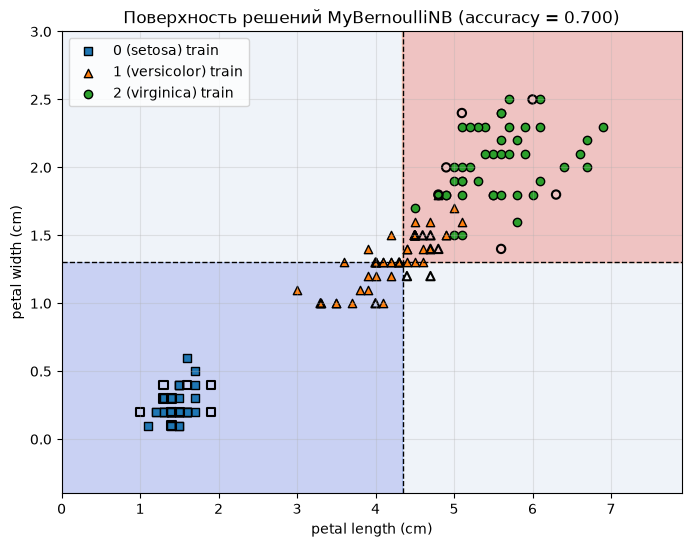

In [54]:
medians = np.median(X1_train, axis=0)
print("Медианы признаков:", medians)

def binarize_features(X, medians):
    # 1, если значение >= медианы, иначе 0
    return (X >= medians).astype(int)

Xb_train = binarize_features(X1_train, medians)
Xb_test  = binarize_features(X1_test, medians)
print(Xb_train[:5])

class MyBernoulliNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X_train, y_train):
        X = np.asarray(X_train)
        y = np.asarray(y_train)

        self.classes_ = np.unique(y)
        n_classes, n_features = len(self.classes_), X.shape[1]

        self.log_prior_ = np.zeros(n_classes)       # log P(c)
        self.p1_ = np.zeros((n_classes, n_features)) # P(x_i = 1 | c)

        for i, c in enumerate(self.classes_):
            Xc = X[y == c]
            self.log_prior_[i] = np.log(len(Xc) / len(X))
            # сглаживание Лапласа: (число единиц + alpha) / (число объектов + 2*alpha)
            self.p1_[i] = (Xc.sum(axis=0) + self.alpha) / (len(Xc) + 2 * self.alpha)
        return self

    def predict_log_proba(self, X_test):
        X = np.asarray(X_test)
        log_post = np.zeros((X.shape[0], len(self.classes_)))
        for i in range(len(self.classes_)):
            p = self.p1_[i]
            # x_i = 1 -> log P(x_i=1|c);  x_i = 0 -> log(1 - P(x_i=1|c))
            log_lik = X * np.log(p) + (1 - X) * np.log(1 - p)
            log_post[:, i] = self.log_prior_[i] + log_lik.sum(axis=1)
        return log_post

    def predict(self, X_test):
        return self.classes_[np.argmax(self.predict_log_proba(X_test), axis=1)]


bnb = MyBernoulliNB().fit(Xb_train, y1_train)

print(f"Accuracy MyBernoulliNB (4 признака): {accuracy_score(y1_test, bnb.predict(Xb_test)):.4f}")

cols = [2, 3]
feat_names = ['petal length (cm)', 'petal width (cm)']
med2 = medians[cols]

bnb2 = MyBernoulliNB().fit(binarize_features(X1_train[:, cols], med2), y1_train)
acc2 = accuracy_score(y1_test, bnb2.predict(binarize_features(X1_test[:, cols], med2)))
print(f"Accuracy (пара признаков): {acc2:.4f}")

X_2d = X1[:, cols]
xx, yy = np.meshgrid(
    np.linspace(X_2d[:, 0].min() - 1,   X_2d[:, 0].max() + 1,   400),
    np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = bnb2.predict(binarize_features(grid, med2)).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
for c, marker, name in zip([0, 1, 2], ['s', '^', 'o'], load_iris().target_names):
    m = y1_train == c
    plt.scatter(X1_train[m, cols[0]], X1_train[m, cols[1]], marker=marker,
                edgecolor='k', label=f'{c} ({name}) train')
    m = y1_test == c
    plt.scatter(X1_test[m, cols[0]], X1_test[m, cols[1]], marker=marker,
                edgecolor='k', facecolor='none', linewidth=1.5)
plt.axvline(med2[0], color='k', ls='--', lw=1)   # пороги бинаризации
plt.axhline(med2[1], color='k', ls='--', lw=1)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f'Поверхность решений MyBernoulliNB (accuracy = {acc2:.3f})')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Задание 4.6: Категориальный наивный байесовский классификатор (CategoricalNB)

In [56]:
class Discretizer:
    """Разбивает диапазон каждого признака на n_bins интервалов равной ширины."""
    def __init__(self, n_bins=4):
        self.n_bins = n_bins

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.edges_ = [np.linspace(X[:, j].min(), X[:, j].max(), self.n_bins + 1)[1:-1]
                       for j in range(X.shape[1])]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # digitize возвращает номер интервала 0..n_bins-1; значения вне диапазона
        return np.column_stack([np.digitize(X[:, j], self.edges_[j]) for j in range(X.shape[1])])

N_BINS = 4
disc = Discretizer(N_BINS).fit(X1_train)
Xc_train, Xc_test = disc.transform(X1_train), disc.transform(X1_test)
print(Xc_train[:5])

class MyCategoricalNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X_train, y_train, n_categories=None):
        X = np.asarray(X_train, dtype=int)
        y = np.asarray(y_train)

        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        # n_categories_i: сколько всего категорий у признака i
        self.n_categories_ = np.array(n_categories) if n_categories is not None else X.max(axis=0) + 1

        self.log_prior_ = np.zeros(len(self.classes_))
        # log_prob_[i][c, t] = log P(x_i = t | c)
        self.log_prob_ = [np.zeros((len(self.classes_), self.n_categories_[i]))
                          for i in range(n_features)]

        for k, c in enumerate(self.classes_):
            Xc = X[y == c]
            self.log_prior_[k] = np.log(len(Xc) / len(X))              # log P(c)
            for i in range(n_features):
                # N_tic: сколько объектов класса c имеют значение t у признака i
                counts = np.bincount(Xc[:, i], minlength=self.n_categories_[i])
                # (N_tic + alpha) / (N_c + alpha * n_categories_i)
                self.log_prob_[i][k] = np.log((counts + self.alpha) /
                                              (len(Xc) + self.alpha * self.n_categories_[i]))
        return self

    def predict_log_proba(self, X_test):
        X = np.asarray(X_test, dtype=int)
        log_post = np.tile(self.log_prior_, (X.shape[0], 1))   # log P(c)
        for i in range(X.shape[1]):
            # для каждого объекта берём log P(x_i = t | c) для его категории t
            log_post += self.log_prob_[i][:, X[:, i]].T
        return log_post

    def predict(self, X_test):
        return self.classes_[np.argmax(self.predict_log_proba(X_test), axis=1)]


# 4 признака
cat = MyCategoricalNB().fit(Xc_train, y1_train, n_categories=[N_BINS] * 4)
gnb = MyGaussianNB().fit(X1_train, y1_train)

print(f"MyCategoricalNB (дискретизированные): {accuracy_score(y1_test, cat.predict(Xc_test)):.4f}")
print(f"MyGaussianNB (исходные):              {accuracy_score(y1_test, gnb.predict(X1_test)):.4f}")

# влияние числа бинов
for nb in (3, 4, 5):
    d = Discretizer(nb).fit(X1_train)
    m = MyCategoricalNB().fit(d.transform(X1_train), y1_train, n_categories=[nb] * 4)
    print(f"бинов={nb}: accuracy={accuracy_score(y1_test, m.predict(d.transform(X1_test))):.4f}")

[[2 1 3 2]
 [1 1 2 2]
 [1 2 0 0]
 [2 1 2 2]
 [2 1 3 3]]
MyCategoricalNB (дискретизированные): 0.9333
MyGaussianNB (исходные):              0.9667
бинов=3: accuracy=0.9000
бинов=4: accuracy=0.9333
бинов=5: accuracy=0.9333
